In [66]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import plotly.subplots as sp
import plotly.graph_objects as go

In [67]:
!pip install openpyxl --quiet

# Motivation

- What is your dataset?
- Why did you choose this/these particular dataset(s)?
- What was your goal for the end user's experience?

We don't use one dataset. We aggregate data from multiple sources and try to connect the dots between UK's births and economic indicators.
We use the data from the ONS Vital Statistics and data.gov.uk to get the birth data and the population data.

We chose these particular datasets as we aim to create a nationwide story and try to answer the question of why UK's births are declining.
We feel like there's a lot of talk about the UK's birth rate, but not a lot of analysis on why is it declining - especially not on the Gen Z social media like TikTok or Instagram.

We want to start with a simple introduction and proof that UK's births are declining. This is our baseline. Then, we provide the economic factors over the same period to see if there are some connections (not necessarily causation though). Finally, we give the user space to explore the data on a more granular level.


# Basic Stats 
-  Write about your choices in data cleaning and preprocessing
- For the data cleaning of the datasets used for the regional section of the story, the data was first manually preprocessed to extract the relevant tables and then columns, and columns named harmonized. then this was exported to a set of csv files. 
this was done to make the programmatic merging of data into the combined data set easier. when actually processing this data, the ONS location codes were used as anchors between tables, so as to map the year and other indicators onto the birthrate tables. 

# Data Analysis 
- Describe your data analysis and explain what you've learned about the dataset.
-  If relevant, talk about your machine-learning.

Looking at the data we noticed that the birth rate in uk is indeed declining, although interestingly enough the female population has increased. That is not taking into consideration if that might be due to increased life expectancy, and if the amount of women of fertile age indeed is higher now than before.
Furthermore we learned that the GDP per capita and the Household Disposable Income have been steadily increasing over the last 30 years. The GDP has gone up by 113.73%, and Household Disposable Income by 52.53%. Meanwhile, the housing prices have gone dramatically up by 298.18% in the same period.

LLM where used to help us code plots and data processing in pythons when needed, but analysis of the data and article writing is all us.

# Genre 
-  Which tools did you use from each of the 3 categories of Visual Narrative (Figure 7 in Segal and Heer). Why?
-  Which tools did you use from each of the 3 categories of Narrative Structure (Figure 7 in Segal and Heer). Why?

We chose the magazine-style genre as it's most applicable to the story we're telling. 

For the Narrative Structure tools, we used "Hover Highlighting / Details" to provide our readers with more information on the data when they hover over the graphs.
Also, "captions", "annotations" and "introductory text" were used to give more context on the data and the story we're telling.

When it comes to Visual Narratives, we did not use the presented tools, as our style does not match the animated vibe. It's more of a compelling book style rather than a flashy powerpoint presentation.


# Visualizations 
-  Explain the visualizations you've chosen.
-  Why are they right for the story you want to tell?

- We chose to present the birth rate and economic factors as linear graphs, as it gives a good visualization of how these factors have changes over the year, showing clear ups and down trends corresponding to historical events and growth. But we also didn't want to leave them "soulless", so in order to guide the reader through the story, we added some annotations and captions to the graphs as well as on hover animations.
- For the regional and temporal difference visualizations plots were chosen between it gives a good way to easily compare the data, while also being easy to make sense of. 
# Discussion. Think critically about your creation
-  What went well?,
- What is still missing? What could be improved?, Why?

- It could have been interesting to look at other factors, such as education levels, enviromental factors, social factors and even some other economic factors that might play into the fall in birth rate and see if there might be something else that more closely correlates or catches our interest. But doing that would require a lot of data, that may or may not exsist, and would be out of scope for this project.
- We also feel like we could deepen our story a bit - even mentioning the factors of differenent generations, standards, and preferences might engage the reader more and make the story more interesting.
- For the regional data ideally we would have found a disposable income dataset per location code that spanned a longer time period and combined it housing and birth rates for that same period. as it stands the data used in that section of the story, while able to give an indication, still very weak as an indicator of actual relationships.

# Contributions 
-  You should write (just briefly) which group member was the main responsible for which elements of the assignment. (I want you guys to understand every part of the assignment, but usually there is someone who took lead role on certain portions of the work. That's what you should explain).
-  It is not OK simply to write "All group members contributed equally".

Hubert made the video for project presentation A, set up the html page, introduction and the first section of the story.
Karitas researched useful datasets, came up with a preliminary idea of what the project could be about and worked on the second section of the story.
Theodor worked on visualization 3, including finding additional required datasets for it and processing this into visualizations and then text about it. 

In [68]:
births_df = pd.read_csv('data/live-births-england-and-wales-1938-2024.csv')
ukpopulation_raw_df = pd.read_excel('data/ukpopulationestimates18382022.xlsx', sheet_name='Table 7', header=3)
house_prices_df = pd.read_csv('data/average-house-prices.csv')
CPIH_df = pd.read_csv('data/CPIH.csv')
GDP_df = pd.read_csv('data/GDP.csv')
household_dis_income_df = pd.read_csv('data/Median-and-mean-household-income.csv')


In [69]:
class DataCleaner:
    @staticmethod
    def clean_ukpopulation_df(df):
        df = df.dropna(subset=["Year"])
        df = df[~df["Year"].str.contains("Note:")]
        df["Year"] = df["Year"].str.replace("Mid-", "").astype(int)

        return df

In [70]:
ukpopulation_df = DataCleaner.clean_ukpopulation_df(ukpopulation_raw_df)

In [71]:
plot_df = ukpopulation_df.merge(births_df, on="Year", how="inner").sort_values("Year")

BG = "#F5F2ED"
ACCENT = "#1A1A2E"
META = "#6B7280"
RULE = "#C8C2B8"

CALLOUTS = [
    dict(year=1950, title="1950", subtitle="Post-War Reconstruction", dx=-38, dy=46),
    dict(year=1977, title="1977", subtitle="Thatcher's Era Starts", dx=-20, dy=46),
    dict(year=1992, title="1992", subtitle="Black Wednesday", dx=8, dy=46),
    dict(year=2008, title="2008", subtitle="Financial crisis", dx=8, dy=46),
    dict(year=2020, title="2020", subtitle="COVID-19", dx=20, dy=40),
]

def plot_births(df, year_range=None, callouts=()):
    d = df.copy()
    if year_range:
        d = d[(d["Year"] >= year_range[0]) & (d["Year"] <= year_range[1])]

    fig, ax = plt.subplots(figsize=(9, 4.2), facecolor=BG)
    ax.set_facecolor(BG)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(RULE)

    ax.grid(axis="y", linestyle="--", color=RULE, alpha=0.85)
    ax.tick_params(colors=META, labelsize=9)
    ax.set_xlabel("Year", color=META, fontsize=10)
    ax.set_ylabel("Live births (E&W)", color=META, fontsize=10)
    ax.set_title("Live births in England & Wales", color=ACCENT, fontsize=11, pad=10)

    x, y = d["Year"], d["Number of Live Births"]
    ax.fill_between(x, y, alpha=0.2, color=ACCENT)
    ax.plot(x, y, color=ACCENT, lw=2.2)
    ax.set_ylim(bottom=0)

    for c in callouts:
        row = d[d["Year"] == int(c["year"])]
        if row.empty:
            continue
        yr, yval = int(c["year"]), float(row["Number of Live Births"].iloc[0])
        ax.plot([yr, yr], [0, yval], ls="--", color=ACCENT, lw=1)
        ax.scatter([yr], [yval], color=ACCENT, s=36, zorder=5, ec="white", linewidths=0.8)
        ax.annotate(
            f'{c["title"]}\n{c["subtitle"]}',
            xy=(yr, yval),
            xytext=(c.get("dx", 10), c.get("dy", 14)),
            textcoords="offset points",
            fontsize=8,
            color=ACCENT,
            bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor=ACCENT, linewidth=1),
            arrowprops=dict(arrowstyle="-", color=ACCENT, lw=0.8),
        )

    ax.set_title("Live births in England & Wales (1950–2023)", color=ACCENT, fontsize=11, pad=30)
    fig.tight_layout()
    fig.subplots_adjust(top=0.88) 
    return fig, ax

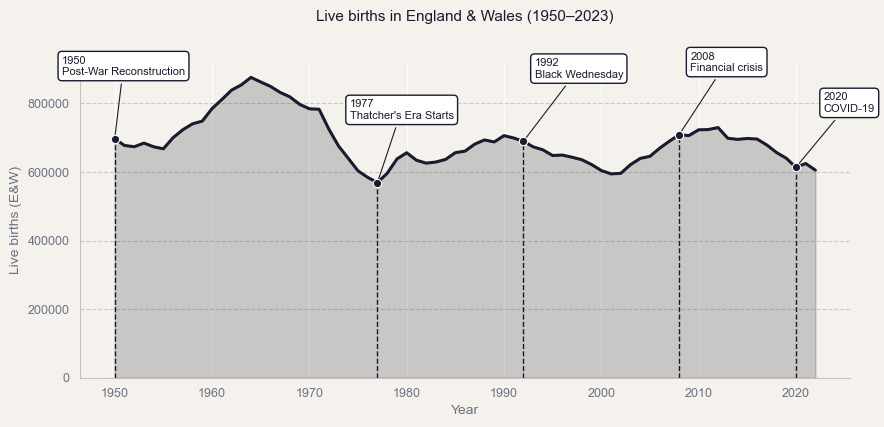

In [72]:
plot_births(plot_df, year_range=(1950, 2023), callouts=CALLOUTS)
plt.show()

In [73]:
decades = (
    ukpopulation_df[ukpopulation_df["Year"] % 10 == 0]
    .sort_values("Year")
    .assign(Females=lambda d: pd.to_numeric(d["Females"], errors="coerce"))
    .assign(Change=lambda d: d["Females"].pct_change() * 100)
    [["Year", "Change", "Females"]]
    .reset_index(drop=True)
    .query("Year >= 1950")
)

avg_change = decades["Change"].mean()
print(f"Average change in female population per decade: {round(avg_change, 2)}%")

f1950, f2020 = decades.loc[decades["Year"].isin([1950, 2020]), "Females"].values
print(f"Change from 1950 to 2020: {round(f1950 / 1000, 2)}k -> {round(f2020 / 1000, 2)}k ({round((f2020 - f1950) / f1950 * 100, 2)}%)")

Average change in female population per decade: 4.32%
Change from 1950 to 2020: 22661.0k -> 30312.28k (33.76%)


In [74]:
# Removing the rows where the region name is not United Kingdom
house_prices_df = house_prices_df[house_prices_df["Region_Name"] == "United Kingdom"]

# Selecting the year
house_prices_df["Year"] = pd.to_datetime(house_prices_df["Date"]).dt.year

# Specifying the year range for the plots
house_prices_df = house_prices_df[house_prices_df["Year"].isin(range(1990, 2024))]
CPIH_df = CPIH_df[CPIH_df["Year"].isin(range(1990, 2024))]
household_dis_income_df = household_dis_income_df[household_dis_income_df["Year"].isin(range(1990, 2024))]
GDP_df = GDP_df[GDP_df["Year"].isin(range(1990, 2024))]

# Sample data and creating side-by-side plots
x1 = GDP_df["Year"]
x2 = CPIH_df["Year"]
x3 = household_dis_income_df["Year"]
x4 = house_prices_df["Year"]

fig = sp.make_subplots(rows=2, cols=2, subplot_titles=("GDP per capita ($)", "Consumer Price Index for Households", "Household Disposable Income (£)", "House Prices (£)"))

fig.add_trace(go.Scatter(x=x1, y=GDP_df["GDP"], mode='lines', name='GDP'), row=1, col=1)
fig.add_trace(go.Scatter(x=x2, y=CPIH_df["CPIH"], mode='lines', name='CPIH'), row=1, col=2)
fig.add_trace(go.Scatter(x=x3, y=household_dis_income_df["Median equivalised household disposable income"], mode='lines', name='HDI'), row=2, col=1)
fig.add_trace(go.Scatter(x=x4, y=house_prices_df["Average_Price"], mode='lines', name='HP'), row=2, col=2)

fig.update_layout(height=600, width=800, title_text="The evolution of four key economic indicators in the UK (1990–2023)")
fig.show()

# Save as standalone HTML
fig.write_html("four_economic_plots.html", include_plotlyjs="cdn", full_html=True)
print("Plotly figure saved as four_economic_plots.html")


Plotly figure saved as four_economic_plots.html


In [75]:
#Researching the changes in the four indicators from 1990 to 2020
print(f"Change in GDP from 1990 to 2020: {round(GDP_df[GDP_df['Year'] == 1990]['GDP'].values[0] / 1000, 2)}k -> {round(GDP_df[GDP_df['Year'] == 2020]['GDP'].values[0] / 1000, 2)}k ({round((GDP_df[GDP_df['Year'] == 2020]['GDP'].values[0] - GDP_df[GDP_df['Year'] == 1990]['GDP'].values[0]) / GDP_df[GDP_df['Year'] == 1990]['GDP'].values[0] * 100, 2)}%)")
print(f"Change in CPIH from 1990 to 2020: {round(CPIH_df[CPIH_df['Year'] == 1990]['CPIH'].values[0], 2)} -> {round(CPIH_df[CPIH_df['Year'] == 2020]['CPIH'].values[0], 2)} ({round((CPIH_df[CPIH_df['Year'] == 2020]['CPIH'].values[0] - CPIH_df[CPIH_df['Year'] == 1990]['CPIH'].values[0]) / CPIH_df[CPIH_df['Year'] == 1990]['CPIH'].values[0] * 100, 2)}%)")
print(f"Change in Household Disposable Income from 1990 to 2020: {round(household_dis_income_df[household_dis_income_df['Year'] == 1990]['Median equivalised household disposable income'].values[0], 2)} -> {round(household_dis_income_df[household_dis_income_df['Year'] == 2020]['Median equivalised household disposable income'].values[0], 2)} ({round((household_dis_income_df[household_dis_income_df['Year'] == 2020]['Median equivalised household disposable income'].values[0] - household_dis_income_df[household_dis_income_df['Year'] == 1990]['Median equivalised household disposable income'].values[0]) / household_dis_income_df[household_dis_income_df['Year'] == 1990]['Median equivalised household disposable income'].values[0] * 100, 2)}%)")
print(f"Change in House Prices from 1990 to 2020: {round(house_prices_df[house_prices_df['Year'] == 1990]['Average_Price'].values[0] / 1000, 2)}k -> {round(house_prices_df[house_prices_df['Year'] == 2020]['Average_Price'].values[0] / 1000, 2)}k ({round((house_prices_df[house_prices_df['Year'] == 2020]['Average_Price'].values[0] - house_prices_df[house_prices_df['Year'] == 1990]['Average_Price'].values[0]) / house_prices_df[house_prices_df['Year'] == 1990]['Average_Price'].values[0] * 100, 2)}%)")

Change in GDP from 1990 to 2020: 19.1k -> 40.81k (113.73%)
Change in CPIH from 1990 to 2020: 8.0 -> 1.0 (-87.5%)
Change in Household Disposable Income from 1990 to 2020: 24042 -> 36671 (52.53%)
Change in House Prices from 1990 to 2020: 53.66k -> 213.66k (298.18%)


In [80]:
# viz 3 data processing
def create_dataset():
    # 1. Read births data for 2020 to establish the baseline codes and region hierarchy
    df_2020 = pd.read_csv('data/births - 2020.csv', header=3)
    df_2020 = df_2020.dropna(subset=['Code'])
    valid_codes = df_2020['Code'].tolist()

    # Build a hierarchy map from Code to parent Codes
    code_to_parents = {}
    current_country = None
    current_region = None
    current_county = None
    current_met_county = None

    # Keep track of the original order of the valid codes
    code_order = {code: i for i, code in enumerate(valid_codes)}

    for _, row in df_2020.iterrows():
        geo = str(row['Geography']).strip()
        code = str(row['Code']).strip()
        name = str(row['Name']).strip()

        if geo == 'Country':
            current_country = code
            current_region = None
            current_county = None
            current_met_county = None
            if name == 'WALES':
                current_region = code # Treat WALES as a region
        elif geo == 'Region':
            current_region = code
            current_county = None
            current_met_county = None
        elif geo == 'County':
            current_county = code
            current_met_county = None
        elif geo == 'Metropolitan County':
            current_met_county = code
            current_county = None

        code_to_parents[code] = {
            'Country': current_country,
            'Region': current_region,
            'County': current_county,
            'Metropolitan County': current_met_county,
            'Name': name,
            'Geography': geo
        }

    # 2. Read births data for each year
    births_dfs = []
    for year in range(2020, 2025):
        header_row = 4 if year == 2024 else 3
        try:
            df = pd.read_csv(f'data/births - {year}.csv', header=header_row)
            df = df.dropna(subset=['Code'])

            df = df[df['Code'].isin(valid_codes)]

            df = df.rename(columns={'Code': 'code', 'Name': 'local_name', 'Geography': 'geography_type',
                                    'Number of live births': 'number_of_live_births',
                                    'Total Fertility Rate (TFR)': 'total_fertility_rate'})
            df['year'] = year
            births_dfs.append(df)
        except Exception as e:
            pass

    births = pd.concat(births_dfs, ignore_index=True)

    births = births.drop_duplicates(subset=['code', 'year'])

    births['number_of_live_births'] = births['number_of_live_births'].astype(str).str.replace(',', '').apply(pd.to_numeric, errors='coerce')
    births['total_fertility_rate'] = pd.to_numeric(births['total_fertility_rate'], errors='coerce')

    # 3. Read and combine economic data
    def read_and_melt(filepath, value_name):
        df = pd.read_csv(filepath, header=1)
        df = df.rename(columns={'Local authority code': 'code'})


        df = df.drop_duplicates(subset=['code'])


        df = df.drop(columns=['Local authority name', 'Country/Region name', 'Country/Region code'], errors='ignore')
        df_melted = df.melt(id_vars=['code'], var_name='year', value_name=value_name)
        df_melted['year'] = df_melted['year'].astype(int)
        df_melted[value_name] = pd.to_numeric(df_melted[value_name].astype(str).str.replace(',', ''), errors='coerce')
        return df_melted

    housing = read_and_melt('data/births - housing prices 2020-2024.csv', 'median_house_price')
    income = read_and_melt('data/births - income 2020-2024.csv', 'gross_annual_earnings')
    ratio = read_and_melt('data/births - Ratio 2020-2024.csv', 'ratio_earnings_to_house_price')

    eco_df = housing.merge(income, on=['code', 'year'], how='outer')
    eco_df = eco_df.merge(ratio, on=['code', 'year'], how='outer')

    # 4. Merge births and economic data
    final_df = pd.merge(births, eco_df, on=['code', 'year'], how='left')

    # 5. Fill missing economic values using the hierarchy
    eco_cols = ['median_house_price', 'gross_annual_earnings', 'ratio_earnings_to_house_price']

    # Pre-calculate averages for all codes based on their children
    avg_cache = {}
    for year in range(2020, 2025):
        year_data = final_df[final_df['year'] == year]
        for col in eco_cols:
            # We want to aggregate the local authority data to build averages for the higher levels
            # Local authorities are typically Non-metropolitan District, Unitary Authority, London Borough, Metropolitan District
            la_data = year_data[~year_data['geography_type'].isin(['Country', 'Region', 'County', 'Metropolitan County'])]

            # Map each LA to its parents and group
            def get_parent_val(row_code, level):
                parents = code_to_parents.get(row_code, {})
                return parents.get(level)

            # For each level, calculate the mean of the LAs within it
            for level in ['Metropolitan County', 'County', 'Region', 'Country']:
                la_with_parent = la_data.copy()
                la_with_parent['parent_code'] = la_with_parent['code'].apply(lambda x: get_parent_val(x, level))

                # Drop rows where parent is None
                la_with_parent = la_with_parent.dropna(subset=['parent_code'])

                # Calculate mean
                means = la_with_parent.groupby('parent_code')[col].mean().to_dict()

                for parent_code, mean_val in means.items():
                    avg_cache[(parent_code, year, col)] = mean_val

    # Fill the missing values
    for i, row in final_df.iterrows():
        code = row['code']
        year = row['year']

        for col in eco_cols:
            if pd.isna(row[col]):
                # check If we computed an average for this specific code
                if (code, year, col) in avg_cache:
                    final_df.at[i, col] = avg_cache[(code, year, col)]
                else:
                    # Otherwise look up the hierarchy
                    parents = code_to_parents.get(code, {})
                    for level in ['Metropolitan County', 'County', 'Region', 'Country']:
                        parent_code = parents.get(level)
                        if parent_code and (parent_code, year, col) in avg_cache:
                            final_df.at[i, col] = avg_cache[(parent_code, year, col)]
                            break

    # Add region name explicitly
    def get_region_name(code):
        parents = code_to_parents.get(code, {})
        region_code = parents.get('Region')

        # If the geography itself is WALES, the region is WALES
        if parents.get('Name') == 'WALES':
            return 'WALES'

        if region_code:
            return code_to_parents.get(region_code, {}).get('Name')

        return None

    final_df.insert(1, 'region_name', final_df['code'].apply(get_region_name))

    # Fill remaining region NaNs with local_name
    final_df['region_name'] = final_df['region_name'].fillna(final_df['local_name'])

    # Add sorting column
    final_df['sort_order'] = final_df['code'].map(code_order)

    # Reorder columns
    final_df = final_df[[
        'code', 'region_name', 'local_name', 'geography_type', 'sort_order', 'year',
        'number_of_live_births', 'total_fertility_rate', 'median_house_price',
        'gross_annual_earnings', 'ratio_earnings_to_house_price'
    ]]

    # Pivot to wide format
    value_cols = ['number_of_live_births', 'total_fertility_rate', 'median_house_price', 'gross_annual_earnings', 'ratio_earnings_to_house_price']

    wide_df = final_df.pivot(index=['code', 'region_name', 'local_name', 'geography_type', 'sort_order'],
                             columns='year',
                             values=value_cols)

    # Flatten the MultiIndex columns to 'indicator_year' format
    wide_df.columns = [f"{col}_{year}" for col, year in wide_df.columns]

    wide_df = wide_df.reset_index()

    # Restore original ordering
    wide_df = wide_df.sort_values('sort_order').drop(columns=['sort_order']).reset_index(drop=True)

    # Drop locations that do not have births data for 2024
    if 'number_of_live_births_2024' in wide_df.columns:
        wide_df = wide_df.dropna(subset=['number_of_live_births_2024']).reset_index(drop=True)

    return wide_df

merged_dataset = create_dataset()
merged_dataset.head()

,code,region_name,local_name,geography_type,number_of_live_births_2020,number_of_live_births_2021,number_of_live_births_2022,number_of_live_births_2023,number_of_live_births_2024,total_fertility_rate_2020,...,gross_annual_earnings_2020,gross_annual_earnings_2021,gross_annual_earnings_2022,gross_annual_earnings_2023,gross_annual_earnings_2024,ratio_earnings_to_house_price_2020,ratio_earnings_to_house_price_2021,ratio_earnings_to_house_price_2022,ratio_earnings_to_house_price_2023,ratio_earnings_to_house_price_2024
0,"K04000001, J99000001","ENGLAND, WALES AND ELSEWHERE","ENGLAND, WALES AND ELSEWHERE",Country,613936.0,624828.0,605479.0,591072.0,594677.0,1.58,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,K04000001,ENGLAND AND WALES,ENGLAND AND WALES,Country,613833.0,624729.0,605342.0,590935.0,594540.0,1.58,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,E92000001,ENGLAND,ENGLAND,Country,585195.0,595948.0,577046.0,563561.0,567708.0,1.59,...,30597.093750,30492.274306,32271.086806,34305.052083,36481.322917,10.139792,9.919514,9.603090,8.929583,8.695417
3,E12000001,NORTH EAST,NORTH EAST,Region,24915.0,25153.0,24701.0,24573.0,24231.0,1.47,...,27634.833333,27229.833333,29279.583333,30835.666667,32771.500000,5.810000,5.359167,5.403333,5.115000,5.025000
4,E06000047,NORTH EAST,County Durham,Unitary Authority,4668.0,4592.0,4505.0,4498.0,4327.0,1.42,...,26609.000000,26219.000000,27737.000000,29384.000000,31421.000000,5.150000,4.690000,4.440000,4.360000,4.340000


In [83]:
# viz 3 plots

# Extract the region data
region_summary = merged_dataset[merged_dataset['geography_type'].isin(['Region', 'Country'])].copy()
regions = ['NORTH EAST', 'NORTH WEST', 'YORKSHIRE AND THE HUMBER', 'EAST MIDLANDS',
           'WEST MIDLANDS', 'EAST', 'LONDON', 'SOUTH EAST', 'SOUTH WEST', 'WALES']
region_summary = region_summary[region_summary['local_name'].isin(regions)].copy()

# Calculate the changes from 2020 to 2024

# TFR absolute change
region_summary['tfr_change_20_24'] = region_summary['total_fertility_rate_2024'] - region_summary['total_fertility_rate_2020']

# TFR % change
region_summary['pct_change_tfr_20_24'] = (region_summary['tfr_change_20_24'] / region_summary['total_fertility_rate_2020']) * 100

# House Price % change
region_summary['pct_change_house_price_20_24'] = ((region_summary['median_house_price_2024'] - region_summary['median_house_price_2020']) / region_summary['median_house_price_2020']) * 100

# Ratio % change
region_summary['pct_change_ratio_20_24'] = ((region_summary['ratio_earnings_to_house_price_2024'] - region_summary['ratio_earnings_to_house_price_2020']) / region_summary['ratio_earnings_to_house_price_2020']) * 100

# ensure ordering is identical for the bar plots
region_summary_sorted = region_summary.sort_values('total_fertility_rate_2024', ascending=False)

Plot saved as images/regional_analysis_2020_2024.png


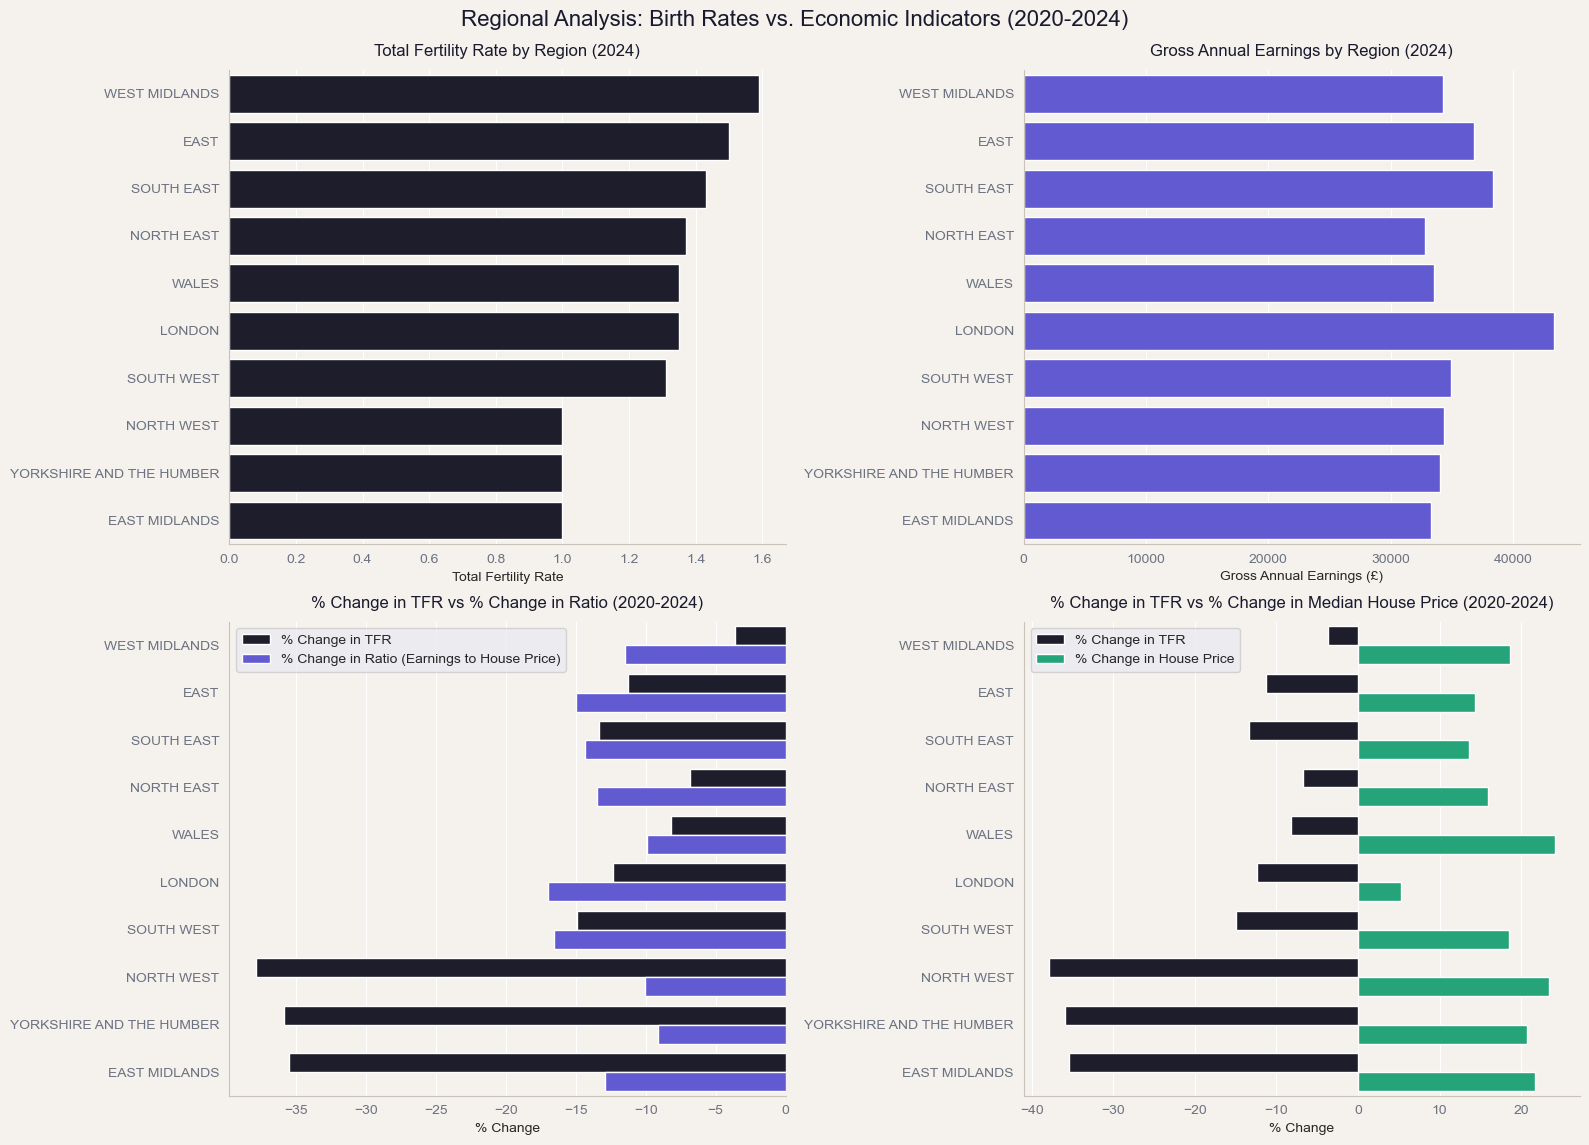

In [84]:

# Create the 2x2 grid of subplots
fig, axs = plt.subplots(2, 2, figsize=(16, 12), facecolor=BG)
fig.suptitle('Regional Analysis: Birth Rates vs. Economic Indicators (2020-2024)', color=ACCENT, fontsize=16, y=0.95)

# Plot 1: Bar plot for birthrate per region in 2024
sns.barplot(data=region_summary_sorted,
            x='total_fertility_rate_2024', y='local_name', ax=axs[0, 0], color=ACCENT)
axs[0, 0].set_title('Total Fertility Rate by Region (2024)', color=ACCENT, pad=10)
axs[0, 0].set_xlabel('Total Fertility Rate')
axs[0, 0].set_ylabel('')
axs[0, 0].set_facecolor(BG)

# Plot 2: Bar plot for median gross income per region in 2024 (using same order as Plot 1)
sns.barplot(data=region_summary_sorted,
            x='gross_annual_earnings_2024', y='local_name', ax=axs[0, 1], color='#4F46E5')
axs[0, 1].set_title('Gross Median Annual Earnings by Region (2024)', color=ACCENT, pad=10)
axs[0, 1].set_xlabel('Gross Median Annual Earnings (£)')
axs[0, 1].set_ylabel('')
axs[0, 1].set_facecolor(BG)

# Plot 3: Bar plot to show correlation in the % change (TFR vs Ratio) between 2020 and 2024
df_melted_change_ratio = region_summary_sorted.melt(id_vars='local_name', value_vars=['pct_change_tfr_20_24', 'pct_change_ratio_20_24'], var_name='Metric', value_name='Percent Change')
df_melted_change_ratio['Metric'] = df_melted_change_ratio['Metric'].replace({'pct_change_tfr_20_24': '% Change in TFR', 'pct_change_ratio_20_24': '% Change in price Ratio (Median earnings to House Price)'})

sns.barplot(data=df_melted_change_ratio, y='local_name', x='Percent Change', hue='Metric', ax=axs[1, 0], palette=[ACCENT, '#4F46E5'])
axs[1, 0].set_title('% Change in TFR vs % Change in Ratio (2020-2024)', color=ACCENT, pad=10)
axs[1, 0].set_xlabel('% Change')
axs[1, 0].set_ylabel('')
axs[1, 0].set_facecolor(BG)
axs[1, 0].legend(title='')

# Plot 4: Bar plot to show correlation in the % change (TFR vs House Price) between 2020 and 2024
df_melted_change_hp = region_summary_sorted.melt(id_vars='local_name', value_vars=['pct_change_tfr_20_24', 'pct_change_house_price_20_24'], var_name='Metric', value_name='Percent Change')
df_melted_change_hp['Metric'] = df_melted_change_hp['Metric'].replace({'pct_change_tfr_20_24': '% Change in TFR', 'pct_change_house_price_20_24': '% Change in House Price'})

sns.barplot(data=df_melted_change_hp, y='local_name', x='Percent Change', hue='Metric', ax=axs[1, 1], palette=[ACCENT, '#10B981'])
axs[1, 1].set_title('% Change in TFR vs % Change in Median House Price (2020-2024)', color=ACCENT, pad=10)
axs[1, 1].set_xlabel('% Change')
axs[1, 1].set_ylabel('')
axs[1, 1].set_facecolor(BG)
axs[1, 1].legend(title='')

# Customize grid and spines for all subplots
for ax in axs.flat:
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(RULE)
    ax.tick_params(colors=META)

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.savefig('images/regional_analysis_2020_2024.png', dpi=300, bbox_inches='tight', facecolor=BG)
print("Plot saved as images/regional_analysis_2020_2024.png")
plt.show()